In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from autoenkoop import *

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
file = np.load("../../data/T1492_x1151_y1_z127_c2.npz")
data = file['timeseries']

In [3]:
class VelocityDataset(Dataset):
    def __init__(self, data):
        # data: numpy array of shape (t, x, z, v)
        self.X = torch.tensor(data[:-1], dtype=torch.float32).permute(0,3,1,2)
        self.Y = torch.tensor(data[1:], dtype=torch.float32).permute(0,3,1,2)
        # Now shape: (t, v=2, x=1151, z=127)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [4]:
dataset = VelocityDataset(data)
loader = DataLoader(dataset, batch_size=12, shuffle=True)

In [5]:
model = ConvAutoencoder(latent_dim=128).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

n_epochs = 100

loss_reconstruction_history = np.zeros((n_epochs))
loss_prediction_history = np.zeros((n_epochs))
loss_linearity_history = np.zeros((n_epochs))
loss_total_history = np.zeros((n_epochs))
steady_mode_number_history = np.zeros((n_epochs))

steady_tolerance = 0.01

def calculate_dynamic_weight(x_t, x_t_reconstructed, x_t_plus_1, x_t_plus_1_reconstructed, alpha = 10):
    with torch.no_grad():
        reconSq_diff_x_t = (x_t.cpu() - x_t_reconstructed.cpu())**2
        reconSq_diff_x_t_plus_1 = (x_t_plus_1.cpu() - x_t_plus_1_reconstructed.cpu())**2
        #print("reconSq_diff_x_t", reconSq_diff_x_t.shape)
        #print("reconSq_diff_x_t_plus_1", reconSq_diff_x_t_plus_1.shape)
        recon_mse_example_x_t = torch.mean(reconSq_diff_x_t,dim=[1,2,3])
        recon_mse_example_x_t_plus_1 = torch.mean(reconSq_diff_x_t_plus_1,dim=[1,2,3])
        #print("recon_mse_example_x_t", recon_mse_example_x_t.shape)
        #print(recon_mse_example_x_t)
        #print("recon_mse_example_x_t_plus_1", recon_mse_example_x_t_plus_1.shape)
        #print(recon_mse_example_x_t_plus_1)
        recon_mse_example = recon_mse_example_x_t + recon_mse_example_x_t_plus_1
        #print("sum")
        #print(recon_mse_example)
        dyn_weight_example = np.exp(-alpha*recon_mse_example.cpu().numpy())
        #print("dynamic weights")
        #print(dyn_weight_example)
    return dyn_weight_example

for epoch in range(n_epochs):

    #if epoch % 20 == 0:
    #    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    
    reconstruction_loss_epoch = 0.0
    prediction_loss_epoch = 0.0
    linearity_loss_epoch = 0.0
    total_loss_epoch = 0.0
    lin_dyn_weight_epoch = 0.0

    for x_t, x_t_plus_1 in loader:
        x_t, x_t_plus_1 = x_t.to(DEVICE), x_t_plus_1.to(DEVICE)
        batch_size = x_t.size(0)

        optimizer.zero_grad()
        
        #encoded current state
        z_t = model.encoder(x_t)
        #decoded current state
        reconstructed_x_t = model.decoder(z_t)
        #linear projected encoded next state
        pz_t_plus_1 = model.linear_dynamics(z_t)

        #encoded next state
        z_t_plus_1 = model.encoder(x_t_plus_1)
        reconstructed_x_t_plus_1 = model.decoder(z_t_plus_1)

        ### RECONSTRUCTION LOSS ###
        loss_reconstruction = mse(x_t, reconstructed_x_t) + mse(x_t_plus_1, reconstructed_x_t_plus_1)
        #lin_dyn_weight_test = calculate_dynamic_weight(x_t, reconstructed_x_t, x_t_plus_1, reconstructed_x_t_plus_1, alpha=2)
        #lin_dyn_weight_epoch += sum(lin_dyn_weight_test)

        #projected decoded next state
        reconstructed_px_t_plus_1 = model.decoder(pz_t_plus_1)

        ### PREDICTION LOSS ###
        loss_prediction = mse(reconstructed_px_t_plus_1, x_t_plus_1)

        ### LINEARITY LOSS ###
        loss_linearity = mse(pz_t_plus_1, z_t_plus_1)
        #loss_linearity = torch.mean(torch.mean(error_linearity,dim=[1]) * torch.tensor(lin_dyn_weight_test).to(DEVICE))

        ### TOTAL LOSS ###
        loss_total = loss_reconstruction + loss_prediction + 0.01*loss_linearity

        loss_total.backward()
        optimizer.step()
        
        reconstruction_loss_epoch += loss_reconstruction.item() * batch_size
        prediction_loss_epoch += loss_prediction.item() * batch_size
        linearity_loss_epoch += loss_linearity.item() * batch_size
        total_loss_epoch += loss_total.item() * batch_size

    # calculate epoch loss mean
    num_examples = len(loader.dataset)

    reconstruction_loss_mean = reconstruction_loss_epoch / num_examples
    prediction_loss_mean = prediction_loss_epoch / num_examples
    linearity_loss_mean = linearity_loss_epoch / num_examples
    total_loss_mean = total_loss_epoch / num_examples
    #lin_dyn_weight_mean = lin_dyn_weight_epoch / num_examples

    
    loss_reconstruction_history[epoch] = reconstruction_loss_mean
    loss_prediction_history[epoch] = prediction_loss_mean
    loss_linearity_history[epoch] = linearity_loss_mean
    loss_total_history[epoch] = total_loss_mean

    with torch.no_grad():
        K = model.linear_dynamics.weight.detach().cpu().numpy()
    eigvals, eigvecs = np.linalg.eig(K)
    
    max_abs_eigenvalue = np.max(np.abs(eigvals))

    mask = np.abs((np.abs(eigvals) - 1.0)) < steady_tolerance
    steady_mode_number_history[epoch] = sum(mask)
        #break
    print(f"Epoch {epoch+1}/{n_epochs}\tLoss(total): {total_loss_mean:.4f}\tLoss(recon): {reconstruction_loss_mean:.4f}\tLoss(pred): {prediction_loss_mean:.4f}\tLoss(lin): {linearity_loss_mean:.6f}\tMaxAbsEigenV: {max_abs_eigenvalue:.4f}\tSteadyModes: {sum(mask)}")

Epoch 1/100	Loss(total): 1.9799	Loss(recon): 1.2899	Loss(pred): 0.6477	Loss(lin): 4.231486	MaxAbsEigenV: 0.8806	SteadyModes: 0
Epoch 2/100	Loss(total): 0.4305	Loss(recon): 0.2805	Loss(pred): 0.1425	Loss(lin): 0.744397	MaxAbsEigenV: 0.8987	SteadyModes: 0
Epoch 3/100	Loss(total): 0.2141	Loss(recon): 0.1392	Loss(pred): 0.0710	Loss(lin): 0.394485	MaxAbsEigenV: 0.9571	SteadyModes: 0
Epoch 4/100	Loss(total): 0.1607	Loss(recon): 0.1049	Loss(pred): 0.0534	Loss(lin): 0.235586	MaxAbsEigenV: 0.9842	SteadyModes: 0
Epoch 5/100	Loss(total): 0.1357	Loss(recon): 0.0889	Loss(pred): 0.0453	Loss(lin): 0.158033	MaxAbsEigenV: 0.9936	SteadyModes: 1
Epoch 6/100	Loss(total): 0.1204	Loss(recon): 0.0787	Loss(pred): 0.0403	Loss(lin): 0.143954	MaxAbsEigenV: 0.9983	SteadyModes: 5
Epoch 7/100	Loss(total): 0.1048	Loss(recon): 0.0684	Loss(pred): 0.0350	Loss(lin): 0.136541	MaxAbsEigenV: 1.0023	SteadyModes: 13
Epoch 8/100	Loss(total): 0.0975	Loss(recon): 0.0634	Loss(pred): 0.0326	Loss(lin): 0.144704	MaxAbsEigenV: 0.998

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "model_20260206_1000.pt")

In [7]:
with torch.no_grad():
    K = model.linear_dynamics.weight.detach().cpu().numpy()
eigvals, eigvecs = np.linalg.eig(K)

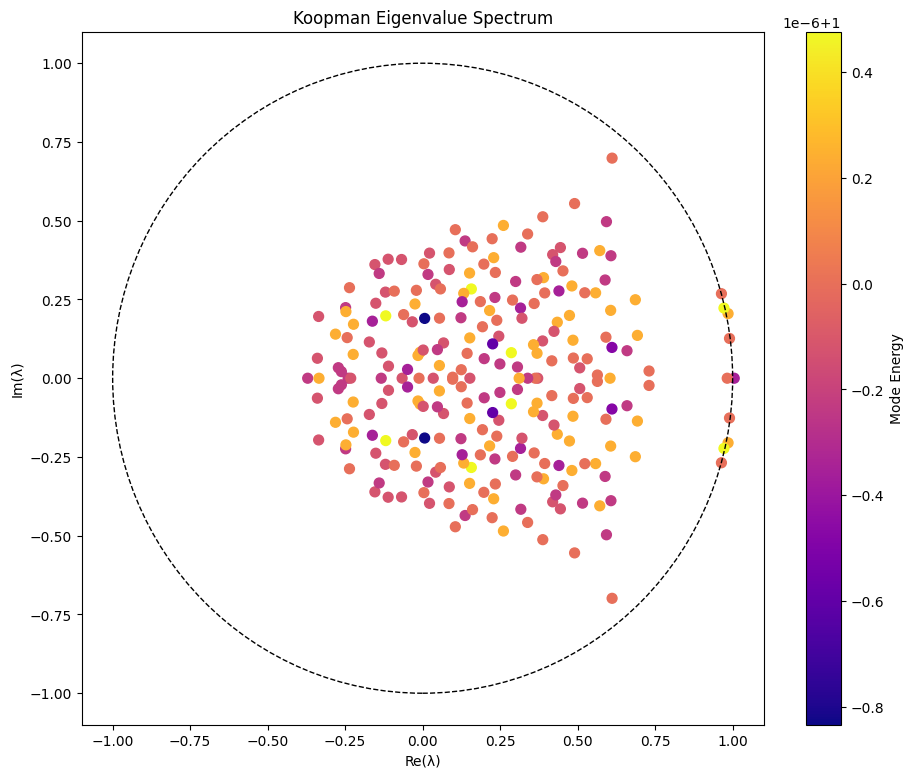

In [8]:
energies = np.linalg.norm(eigvecs, axis=0)**2
total_energy = np.sum(energies)

plt.figure(figsize=(11,9))
plt.axis([-1.1, 1.1, -1.1, 1.1])
sc = plt.scatter(np.real(eigvals), np.imag(eigvals),
                 c=energies, cmap='plasma', s=50)
plt.colorbar(sc, label="Mode Energy")
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Koopman Eigenvalue Spectrum")
circle = plt.Circle((0,0), 1.0, color='k', fill=False, linestyle='--')
plt.gca().add_artist(circle)
#plt.axis('equal')
plt.show()

In [9]:
steady_tolerance = 0.01
# 0.002 => 3
# 0.003 => 7
# 0.004 => 11
# 0.005 => 13
# 0.006 => 15
# 0.01125 => 17
# 0.03 => 21

mask = np.abs((np.abs(eigvals) - 1.0)) < steady_tolerance
eigvals_nondecay = eigvals[mask]
modes_nondecay = eigvecs[:, mask]

nondecay_energy = np.linalg.norm(modes_nondecay, axis=0)**2

explained_energy_ratio = np.sum(nondecay_energy / total_energy)
print(f"{sum(mask)} stable mode explain: {explained_energy_ratio:.3f}% of the energy")

# to torch cuda
E_nondecay = torch.tensor(eigvals_nondecay, dtype=torch.complex64,device=DEVICE)
E_nondecay_normalized = E_nondecay / torch.abs(E_nondecay)
V_nondecay = torch.tensor(modes_nondecay, dtype=torch.complex64, device=DEVICE)

9 stable mode explain: 0.035% of the energy


In [10]:
x0, _ = dataset[0]
x0 = x0.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    z0 = model.encoder(x0)

z0 = z0.squeeze(0).to(torch.complex64)
# Compute coefficients in modal basis
c0 = torch.linalg.pinv(V_nondecay) @ z0

def koopman_evolve(t):
    Lambda_t_diag = torch.diag(torch.exp(torch.log(E_nondecay_normalized) * t))
    z_t_complex = V_nondecay @ Lambda_t_diag @ c0
    return z_t_complex.real.unsqueeze(0)

def reconstruct_state(t):
    z_t_predicted = koopman_evolve(t)
    x_t_reconstructed = model.decoder(z_t_predicted)
    return x_t_reconstructed.squeeze(0)

In [11]:
steady_state_prediction = []
with torch.no_grad():
    for t in range(500):
        reconstructed_x_t = reconstruct_state(t).cpu().numpy()
        steady_state_prediction.append(reconstructed_x_t)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

vx_all = data[..., 0]
vz_all = data[..., 1]

vx_min, vx_max = np.min(vx_all), np.max(vx_all)
vz_min, vz_max = np.min(vz_all), np.max(vz_all)

norm_x = Normalize(vmin=vx_min, vmax=vx_max)
norm_z = Normalize(vmin=vz_min, vmax=vz_max)

def plot_vx_vz(vx, vz):

    plt.figure(figsize=(10,8))

    # --- vx ---
    plt.subplot(2,1,1)
    plt.imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
    plt.colorbar(label='vx')
    plt.title(f"vx")
    plt.xlabel("x-coordinate")
    plt.ylabel("z-coordinate")

    # --- vz ---
    plt.subplot(2,1,2)
    plt.imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
    plt.colorbar(label='vz')
    plt.title(f"vz")
    plt.xlabel("x-coordinate")
    plt.ylabel("z-coordinate")

    plt.tight_layout()
    plt.show()


In [ ]:
x_t_stable = steady_state_prediction[499]
vx = x_t_stable[0,:]
vz = x_t_stable[1,:]

plot_vx_vz(vx, vz)

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

n_timesteps = len(steady_state_prediction)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Initialize first frame
vx = steady_state_prediction[0][0,:]
vz = steady_state_prediction[0][1,:]

im_vx = axes[0].imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
axes[0].set_title("vx at time frame 0")
axes[0].set_xlabel("x-coordinate")
axes[0].set_ylabel("z-coordinate")
fig.colorbar(im_vx, ax=axes[0], label="vx")

im_vz = axes[1].imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
axes[1].set_title("vz")
axes[1].set_xlabel("x-coordinate")
axes[1].set_ylabel("z-coordinate")
fig.colorbar(im_vz, ax=axes[1], label="vz")

plt.tight_layout()

def update(frame):
    print(frame)
    vx = steady_state_prediction[frame][0,:]
    vz = steady_state_prediction[frame][1,:]
    
    im_vx.set_data(vx.T)
    im_vz.set_data(vz.T)
    
    axes[0].set_title(f"vx at time frame {frame}")
    #axes[1].set_title(f"vz")
    
    return [im_vx, im_vz]

ani = FuncAnimation(fig, update,
                    frames=range(500),
                    interval=30,
                    blit=False)

# Save as GIF (requires Pillow)
writer = PillowWriter(fps=20)
ani.save("velocity_field_steadyD_normalized_12_500.gif", writer=writer)

plt.show()

In [ ]:
model.eval()
mse_list = []

with torch.no_grad():
    for x_t_true, x_t_plus_1_true in dataset:
        #vx_true = x_true[0]
        #vz_true = x_true[1]
        #plot_vx_vz(vx_true, vz_true)
        x_true = x_t_true.unsqueeze(0).to('cuda')
        x_pred = model(x_true).squeeze(0).cpu()
        #vx_pred = x_pred[0]
        #vz_pred = x_pred[1]
        #plot_vx_vz(vx_pred, vz_pred)
        #vx_diff = (vx_true - vx_pred)**2
        #vz_diff = (vz_true - vz_pred)**2
        mse_list.append(np.mean((x_true.to('cpu').numpy() - x_pred.numpy())**2))
        #plot_vx_vz(vx_diff, vz_diff)
        #print(np.sum(vz_diff.numpy()))
        #print(np.sum(vz_diff.numpy()))
        #print()
        ##

In [ ]:
mse_list = np.array(mse_list)

In [ ]:
np.mean(mse_list)

In [ ]:
mse_list

In [ ]:
len(dataset)